## Week 1 -- Retail Price Fluctuation Micro Case (M5 Dataset)

**Question**: Do weekly price fluctuations show meaningful patterns (direction, timing, concentration) for a single store + category?

**Scope:** `year=2015`, `store_id=CA_1`, `item_id LIKE 'FOODS%'`, weekly (`wm_yr_wk`).

### Data Inventory

In [0]:
%sql
SHOW TABLES IN workspace.database;

database,tableName,isTemporary
database,calendar,false
database,sales_train_evaluation,false
database,sales_train_validation,false
database,sample_submission,false
database,sell_prices,false


### 2015 week spine

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW Calendar_2015 AS
SELECT *
FROM workspace.database.calendar
WHERE year = 2015;


In [0]:
%sql
SELECT COUNT(*) AS cal_rows FROM Calendar_2015;


cal_rows
365


In [0]:
%sql
CREATE OR REPLACE TEMP VIEW CalendarWeeks_2015 AS
SELECT DISTINCT wm_yr_wk
FROM Calendar_2015;

In [0]:
%sql
SELECT COUNT(DISTINCT wm_yr_wk) AS weeks_2015 FROM CalendarWeeks_2015;


weeks_2015
53


### Week -> Month Mapping (Fixes Daily Duplication)

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW WeekMonth_2015 AS
SELECT wm_yr_wk, MIN(month) AS month
FROM Calendar_2015
GROUP BY wm_yr_wk;

### Filter sell_prices to 2015 weeks

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW Sell_Prices_2015 AS
SELECT sp.*
FROM workspace.database.sell_prices sp
JOIN CalendarWeeks_2015 w
  ON sp.wm_yr_wk = w.wm_yr_wk;


In [0]:
%sql
-- duplicate check
SELECT
  COUNT(*) AS rows,
  COUNT(DISTINCT CONCAT(store_id,'|',item_id,'|',wm_yr_wk)) AS distinct_item_week
FROM Sell_Prices_2015;


rows,distinct_item_week
1601188,1601188


### Scope to CA_1 + FOODS

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW Prices_CA1_FOODS_2015 AS
SELECT *
FROM Sell_Prices_2015
WHERE store_id = 'CA_1'
  AND item_id LIKE 'FOODS%';


In [0]:
%sql
SELECT COUNT(DISTINCT wm_yr_wk) AS weeks_covered
FROM Prices_CA1_FOODS_2015;


weeks_covered
53


### FEATURES (LAG)

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW Prices_CA1_FOODS_2015_Features AS
SELECT
  store_id,
  item_id,
  wm_yr_wk,
  sell_price,
  LAG(sell_price) OVER (PARTITION BY store_id, item_id ORDER BY wm_yr_wk) AS prev_price,
  sell_price - LAG(sell_price) OVER (PARTITION BY store_id, item_id ORDER BY wm_yr_wk) AS price_change
FROM Prices_CA1_FOODS_2015;


In [0]:
%sql
SELECT
  COUNT(*) AS rows,
  COUNT(DISTINCT CONCAT(store_id,'|',item_id,'|',wm_yr_wk)) AS distinct_item_week
FROM Prices_CA1_FOODS_2015_Features;


rows,distinct_item_week
75666,75666


### Metrics

In [0]:
%sql
SELECT COUNT(*) AS change_events
FROM Prices_CA1_FOODS_2015_Features
WHERE price_change IS NOT NULL AND price_change <> 0;


change_events
674


In [0]:
%sql
SELECT
  COUNT(DISTINCT CASE WHEN price_change <> 0 THEN item_id END) AS changed_skus,
  COUNT(DISTINCT item_id) AS total_skus,
  COUNT(DISTINCT CASE WHEN price_change <> 0 THEN item_id END) * 100.0
    / COUNT(DISTINCT item_id) AS pct_skus_changed
FROM Prices_CA1_FOODS_2015_Features;


changed_skus,total_skus,pct_skus_changed
450,1435,31.35888501742160


In [0]:
%sql
SELECT AVG(ABS(price_change)) AS avg_abs_change
FROM Prices_CA1_FOODS_2015_Features
WHERE price_change <> 0;


avg_abs_change
0.34958456973293767


In [0]:
%sql
SELECT
  CASE
    WHEN price_change > 0 THEN 'Increase'
    WHEN price_change < 0 THEN 'Decrease'
  END AS direction,
  COUNT(*) AS change_events
FROM Prices_CA1_FOODS_2015_Features
WHERE price_change <> 0
GROUP BY direction;


direction,change_events
Increase,444
Decrease,230


In [0]:
%sql
WITH changes AS (
  SELECT item_id, COUNT(*) AS change_count
  FROM Prices_CA1_FOODS_2015_Features
  WHERE price_change <> 0
  GROUP BY item_id
),
ranked AS (
  SELECT item_id, change_count,
         ROW_NUMBER() OVER (ORDER BY change_count DESC) AS rn
  FROM changes
),
tot AS (
  SELECT SUM(change_count) AS total_changes
  FROM changes
)
SELECT
  (SUM(CASE WHEN rn <= 10 THEN change_count ELSE 0 END) * 100.0)
  / MAX(total_changes) AS pct_changes_top10
FROM ranked
CROSS JOIN tot;


pct_changes_top10
7.41839762611276


Monthly Normalized Rate (Using WeekMonth_2015)

In [0]:
%sql
WITH base AS (
  SELECT w.month, p.item_id, p.wm_yr_wk, p.price_change
  FROM Prices_CA1_FOODS_2015_Features p
  JOIN WeekMonth_2015 w
    ON p.wm_yr_wk = w.wm_yr_wk
),
active AS (
  SELECT month, COUNT(DISTINCT item_id) AS active_skus
  FROM base
  GROUP BY month
),
changes AS (
  SELECT month, COUNT(*) AS change_events
  FROM base
  WHERE price_change <> 0
  GROUP BY month
)
SELECT
  a.month,
  a.active_skus,
  COALESCE(ch.change_events, 0) AS change_events,
  (COALESCE(ch.change_events, 0) * 1000.0) / a.active_skus AS changes_per_1000_skus
FROM active a
LEFT JOIN changes ch USING (month)
ORDER BY month;


month,active_skus,change_events,changes_per_1000_skus
1,1421,103,72.4841660802252
2,1424,70,49.1573033707865
3,1428,74,51.8207282913165
4,1428,51,35.7142857142857
5,1429,83,58.0825752274318
6,1429,47,32.8901329601120
7,1430,60,41.9580419580420
8,1430,30,20.9790209790210
9,1431,36,25.1572327044025
10,1433,56,39.0788555478018


### Seasonality (monthly counts)

In [0]:
%sql
SELECT w.month, COUNT(*) AS change_events
FROM Prices_CA1_FOODS_2015_Features p
JOIN WeekMonth_2015 w
  ON p.wm_yr_wk = w.wm_yr_wk
WHERE p.price_change <> 0
GROUP BY w.month
ORDER BY w.month;


month,change_events
1,103
2,70
3,74
4,51
5,83
6,47
7,60
8,30
9,36
10,56


### Visualization

**Color palette (consistent across charts)**  
- Light Blue: `#7FB3D5`  
- Light Purple: `#C39BD3`  
- Peak marker: `#2E86C1`  
- Lowest marker: `#8E44AD`  

**Export settings (crisp for GitHub)**  
- `figsize=(10,5)` (or `(7,7)` for donut)  
- `dpi=200`  
- `bbox_inches="tight"`


In [0]:
%python
import matplotlib.pyplot as plt

def save_fig(filename: str):
    tmp_path = f"/tmp/{filename}"
    plt.savefig(tmp_path, dpi=200, bbox_inches="tight")
    try:
        dbutils.fs.cp(f"file:{tmp_path}", f"dbfs:/FileStore/{filename}", True)
        print(f"Saved: dbfs:/FileStore/{filename}")
    except:
        print(f"Saved locally: {tmp_path}")


Monthly Normalized Chart

Saved locally: /tmp/monthly_adjustments_normalized.png


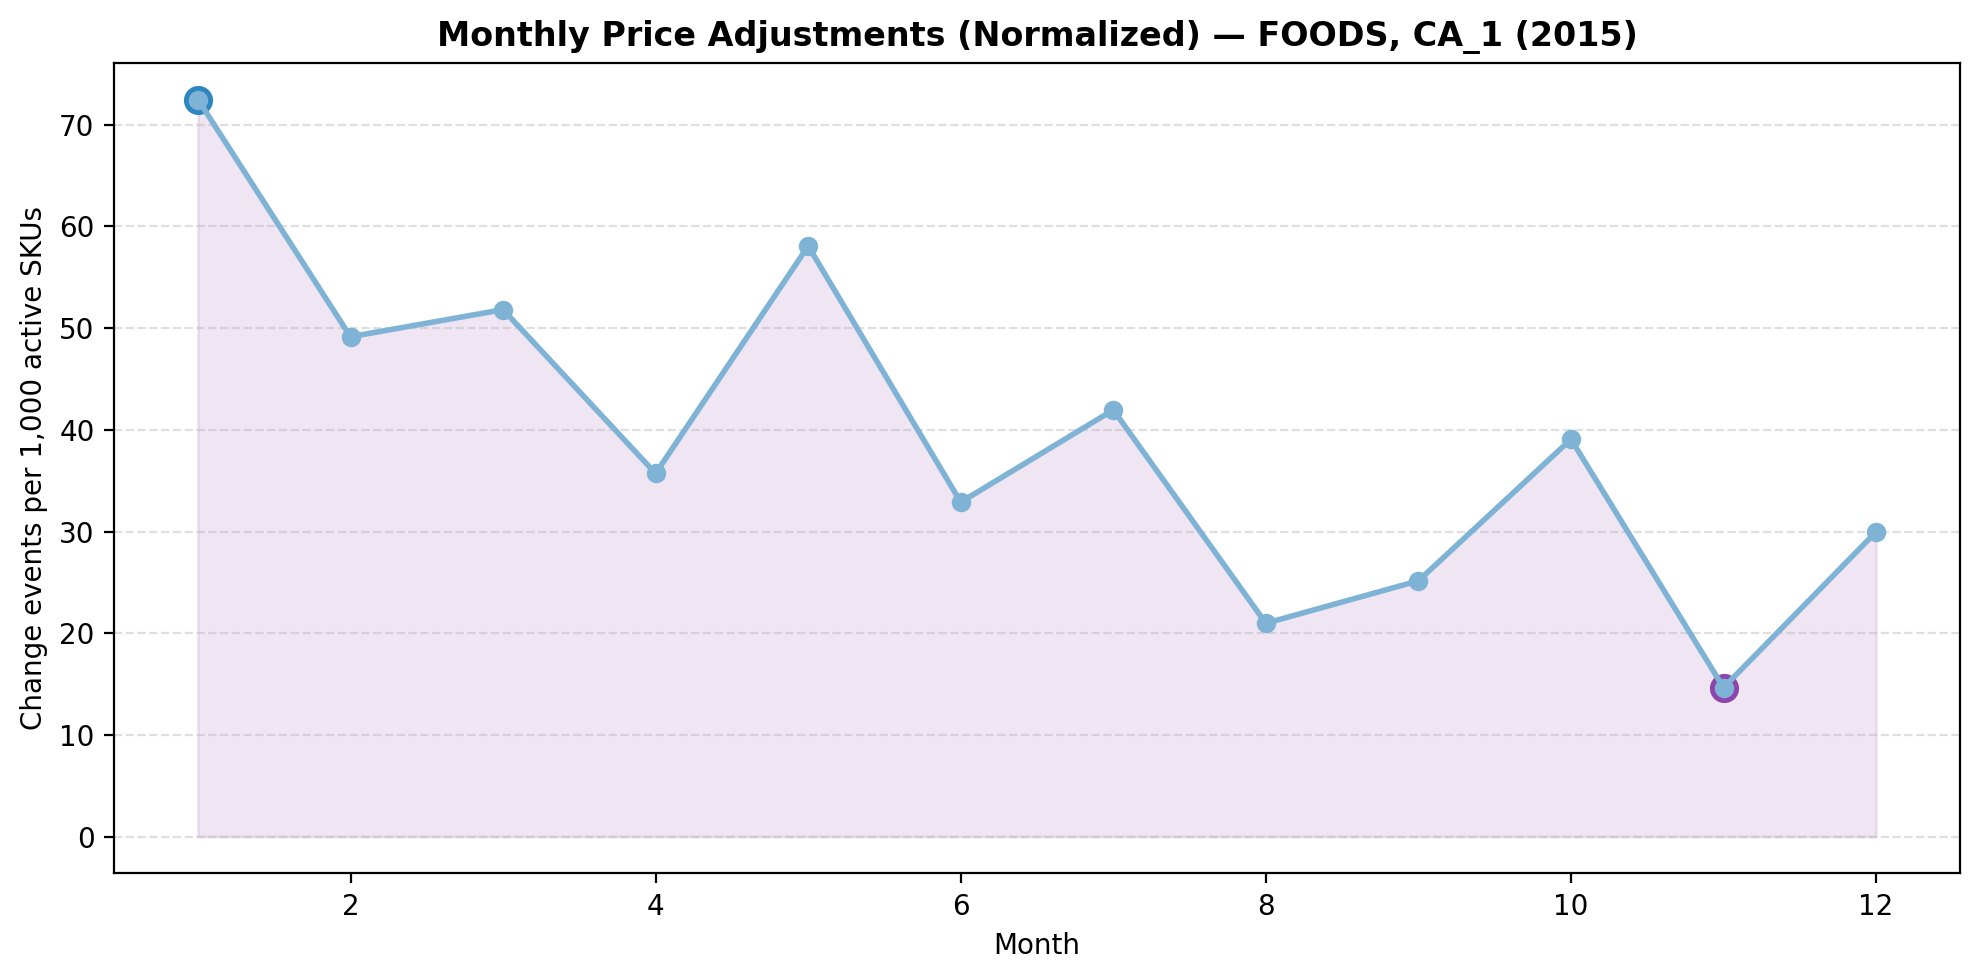

In [0]:
%python
df = spark.sql("""
WITH base AS (
  SELECT
    w.month,
    p.item_id,
    p.wm_yr_wk,
    p.price_change
  FROM Prices_CA1_FOODS_2015_Features p
  JOIN WeekMonth_2015 w
    ON p.wm_yr_wk = w.wm_yr_wk
),
active AS (
  SELECT month, COUNT(DISTINCT item_id) AS active_skus
  FROM base
  GROUP BY month
),
changes AS (
  SELECT month, COUNT(*) AS change_events
  FROM base
  WHERE price_change <> 0
  GROUP BY month
)
SELECT
  a.month,
  a.active_skus,
  COALESCE(ch.change_events, 0) AS change_events,
  (COALESCE(ch.change_events, 0) * 1000.0) / a.active_skus AS changes_per_1000_skus
FROM active a
LEFT JOIN changes ch USING (month)
ORDER BY month
""").toPandas()

plt.figure(figsize=(10,5), dpi=200)
plt.plot(df["month"], df["changes_per_1000_skus"], marker="o", linewidth=2, color="#7FB3D5")
plt.fill_between(df["month"], df["changes_per_1000_skus"], color="#C39BD3", alpha=0.25)

peak_idx = df["changes_per_1000_skus"].idxmax()
low_idx = df["changes_per_1000_skus"].idxmin()

plt.scatter(df.loc[peak_idx,"month"], df.loc[peak_idx,"changes_per_1000_skus"], color="#2E86C1", s=90)
plt.scatter(df.loc[low_idx,"month"], df.loc[low_idx,"changes_per_1000_skus"], color="#8E44AD", s=90)

plt.title("Monthly Price Adjustments (Normalized) — FOODS, CA_1 (2015)", weight="bold")
plt.xlabel("Month")
plt.ylabel("Change events per 1,000 active SKUs")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

save_fig("monthly_adjustments_normalized.png")
plt.show()


Saved locally: /tmp/sku_change_frequency.png


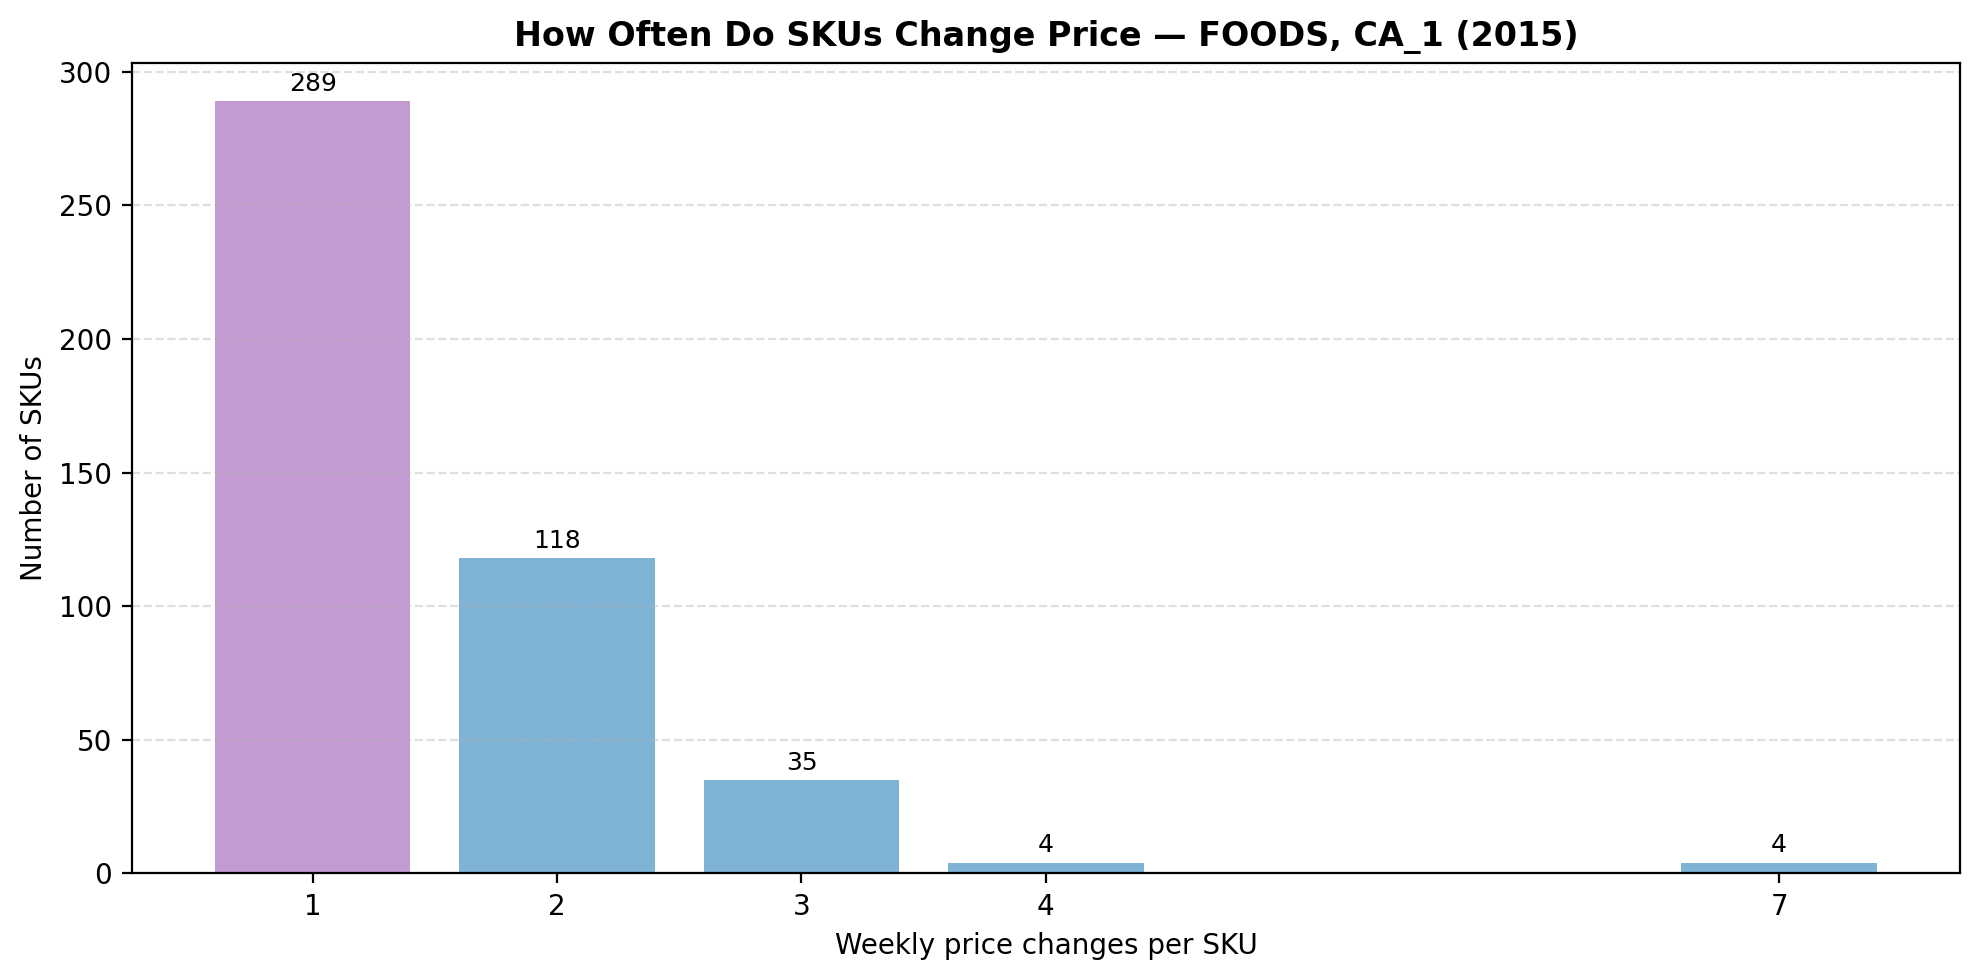

In [0]:
%python
# Distribution: how often SKUs change price
hist = spark.sql("""
WITH per_item AS (
  SELECT item_id, COUNT(*) AS change_count
  FROM Prices_CA1_FOODS_2015_Features
  WHERE price_change <> 0
  GROUP BY item_id
)
SELECT change_count, COUNT(*) AS num_items
FROM per_item
GROUP BY change_count
ORDER BY change_count
""").toPandas()

plt.figure(figsize=(10,5), dpi=200)

# Highlight '1 change' bar in light purple; others light blue
colors = ["#C39BD3"] + ["#7FB3D5"] * (len(hist) - 1)
bars = plt.bar(hist["change_count"], hist["num_items"], color=colors)

# Value labels
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 2, f"{int(h)}",
             ha="center", va="bottom", fontsize=9)

plt.title("How Often Do SKUs Change Price — FOODS, CA_1 (2015)", weight="bold")
plt.xlabel("Weekly price changes per SKU")
plt.ylabel("Number of SKUs")
plt.xticks(hist["change_count"])
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

save_fig("sku_change_frequency.png")
plt.show()


Saved locally: /tmp/donut_direction.png


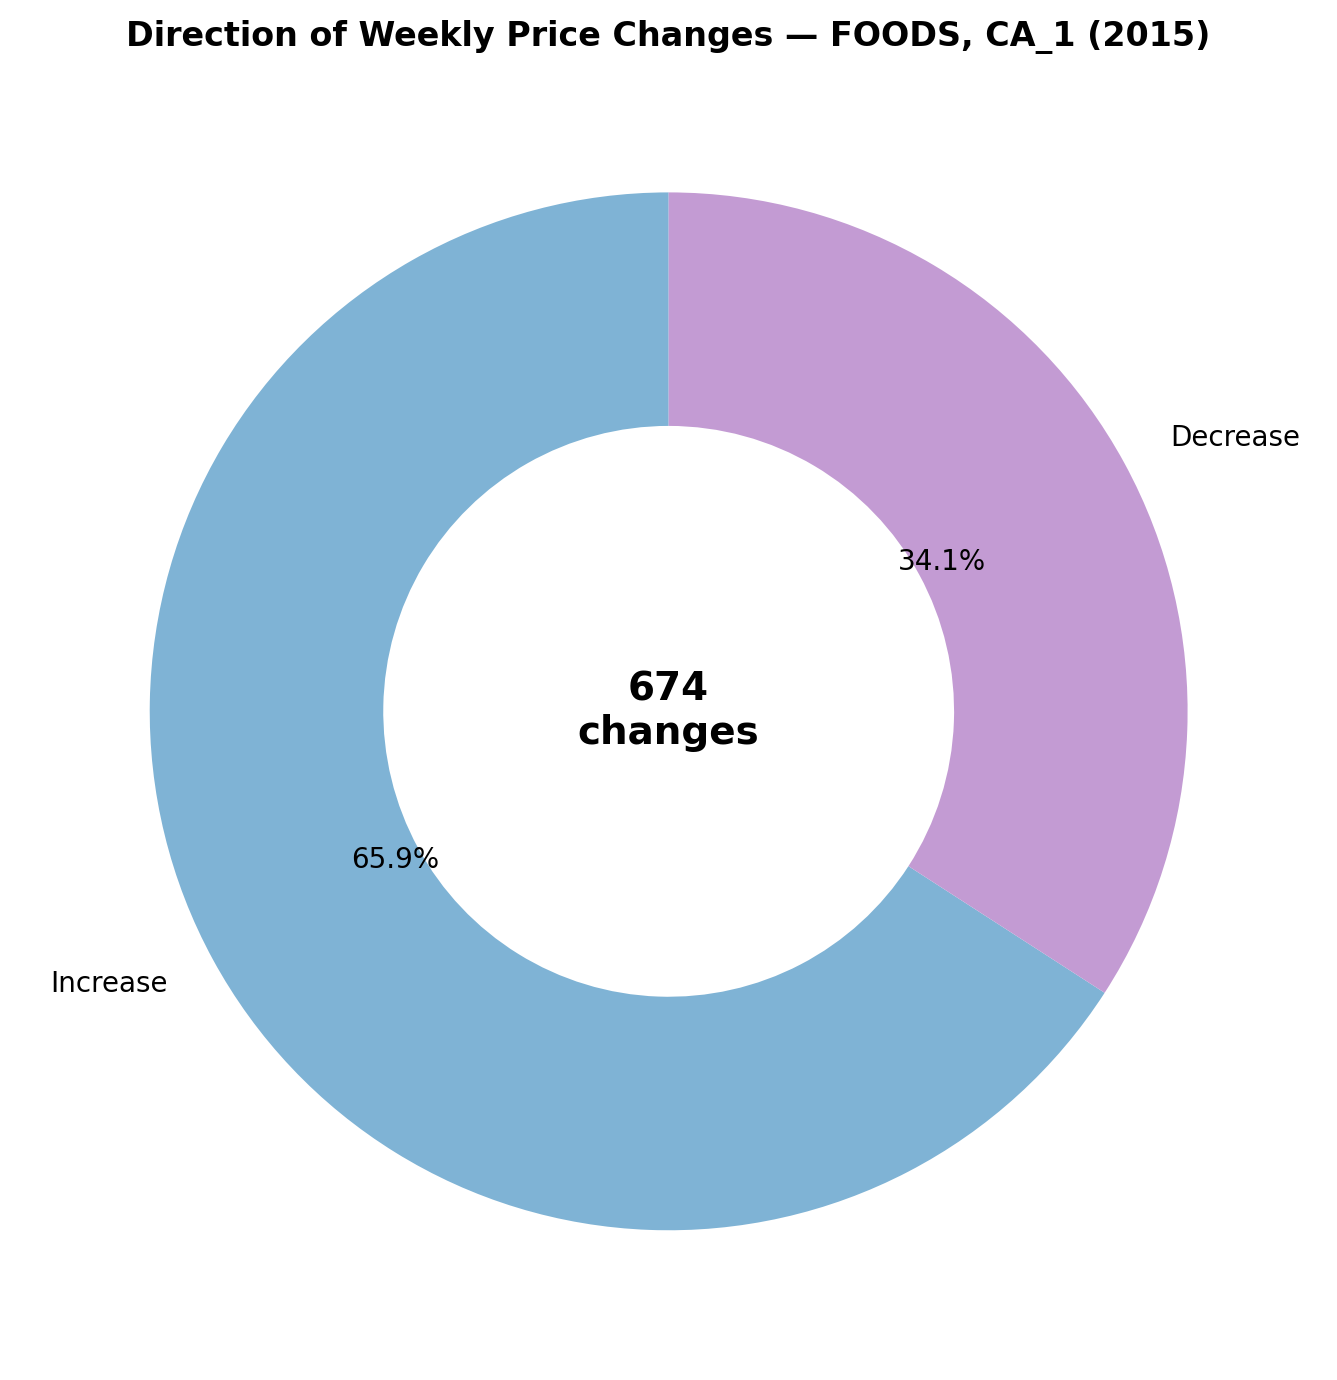

In [0]:
%python
import matplotlib.pyplot as plt

_dir = spark.sql("""
SELECT
  CASE
    WHEN price_change > 0 THEN 'Increase'
    WHEN price_change < 0 THEN 'Decrease'
  END AS direction,
  COUNT(*) AS change_events
FROM Prices_CA1_FOODS_2015_Features
WHERE price_change <> 0
GROUP BY direction
""").toPandas()

labels = _dir["direction"]
values = _dir["change_events"]

plt.figure(figsize=(7,7), dpi=200)
colors = ["#7FB3D5", "#C39BD3"]

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45)
)

plt.text(0, 0, f"{int(values.sum())}\nchanges", ha="center", va="center",
         fontsize=14, weight="bold")

plt.title("Direction of Weekly Price Changes — FOODS, CA_1 (2015)", weight="bold")
plt.tight_layout()

save_fig("donut_direction.png")
plt.show()


### Conclusion
- Weekly price changes are infrequent but directional.
- Changes are distributed across SKUs, not concentrated.
- Window functions (LAG) simplified time-series comparison.